<a href="https://colab.research.google.com/github/Youssiffawzy/BrewCrew-Caf-/blob/Project-delivery/BrewCrew_Caf%C3%A9_(Project_Delivery).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_excel("BrewCrew Café Dataset.xlsx")
df.info()

Saving BrewCrew Café Dataset.xlsx to BrewCrew Café Dataset.xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2000 non-null   datetime64[ns]
 1   Season         2000 non-null   object        
 2   Time           2000 non-null   object        
 3   Time of Day    2000 non-null   object        
 4   Category       2000 non-null   object        
 5   Channel        2000 non-null   object        
 6   Ad Spend       2000 non-null   float64       
 7   Conversions    2000 non-null   int64         
 8   Quantity Sold  2000 non-null   int64         
 9   Revenue        2000 non-null   float64       
 10  Cost           2000 non-null   float64       
 11  Profit         2000 non-null   float64       
 12  Return         2000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(5)
memor

<ipython-input-6-e03270c437f0>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_profit, x='Season', y='Profit', palette='viridis')


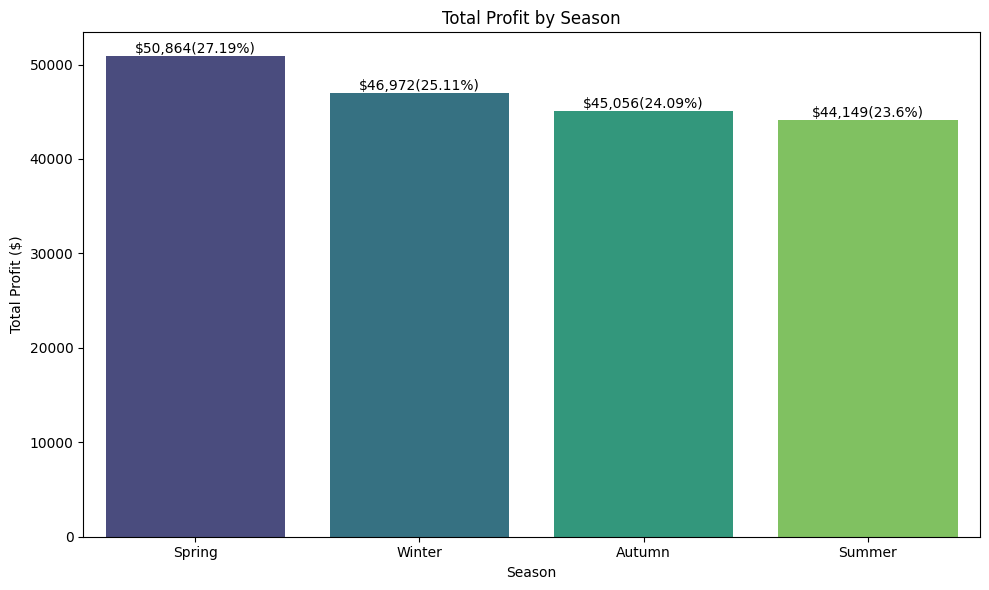

Seasonal Profit Analysis:
   Season    Profit  Percentage
1  Spring  50864.34       27.19
3  Winter  46971.58       25.11
0  Autumn  45055.75       24.09
2  Summer  44149.10       23.60


In [6]:
# Q1: Track sales differences across seasons

# Calculate total profit by season
seasonal_profit = df.groupby('Season')['Profit'].sum().reset_index()

# Sort by profit to see best performing seasons
seasonal_profit = seasonal_profit.sort_values('Profit', ascending=False)

# Calculate percentage of total profit
total_profit = seasonal_profit['Profit'].sum()
seasonal_profit['Percentage'] = (seasonal_profit['Profit'] / total_profit * 100).round(2)

# Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=seasonal_profit, x='Season', y='Profit', palette='viridis')
plt.title('Total Profit by Season')
plt.xlabel('Season')
plt.ylabel('Total Profit ($)')

# Add value labels on top of each bar
for i, v in enumerate(seasonal_profit['Profit']):
    plt.text(i, v, f'${v:,.0f}\
({seasonal_profit["Percentage"].iloc[i]}%)',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Display numerical results
print("\
Seasonal Profit Analysis:")
print(seasonal_profit)

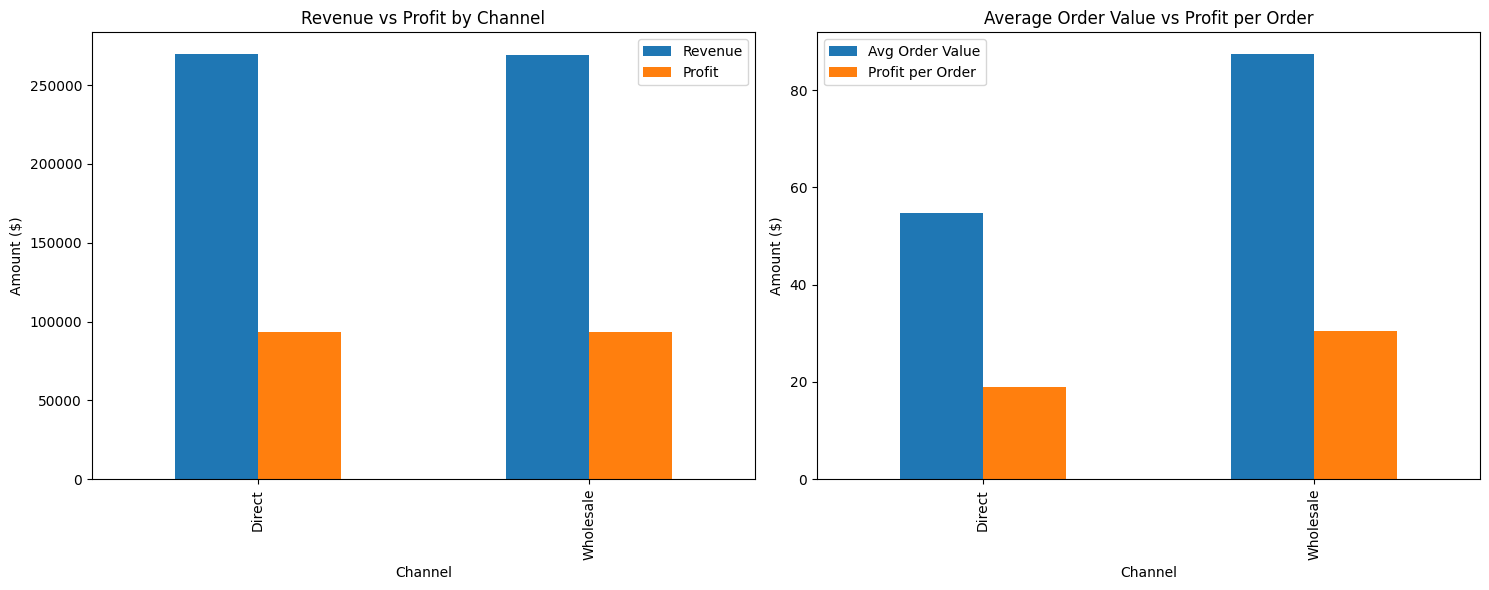

Channel Performance Analysis:
           Quantity Sold    Revenue    Profit  Conversions  Avg Order Value  \
Channel                                                                       
Direct              2505  270019.71  93633.87         4940            54.66   
Wholesale           2534  268860.03  93406.90         3072            87.52   

           Profit per Order  
Channel                      
Direct                18.95  
Wholesale             30.41  


In [7]:
# Q2: Analyze wholesale vs direct customer behavior

# Calculate key metrics by channel
channel_analysis = df.groupby('Channel').agg({
    'Quantity Sold': 'sum',
    'Revenue': 'sum',
    'Profit': 'sum',
    'Conversions': 'sum'
}).round(2)

# Calculate average order value and profit per order
channel_analysis['Avg Order Value'] = (channel_analysis['Revenue'] / channel_analysis['Conversions']).round(2)
channel_analysis['Profit per Order'] = (channel_analysis['Profit'] / channel_analysis['Conversions']).round(2)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Revenue vs Profit by Channel
metrics = pd.DataFrame({
    'Revenue': channel_analysis['Revenue'],
    'Profit': channel_analysis['Profit']
}).plot(kind='bar', ax=ax1)
ax1.set_title('Revenue vs Profit by Channel')
ax1.set_ylabel('Amount ($)')

# Average Order Value and Profit per Order
metrics = pd.DataFrame({
    'Avg Order Value': channel_analysis['Avg Order Value'],
    'Profit per Order': channel_analysis['Profit per Order']
}).plot(kind='bar', ax=ax2)
ax2.set_title('Average Order Value vs Profit per Order')
ax2.set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

print("\
Channel Performance Analysis:")
print(channel_analysis)

In [9]:
# Export data with channel analysis for Tableau
import pandas as pd

# Create channel analysis summary
channel_summary = df.groupby(['Channel', 'Season', 'Category'])[['Quantity Sold', 'Revenue', 'Cost', 'Profit', 'Conversions']].sum().reset_index()

# Calculate additional metrics
channel_summary['Avg Order Value'] = channel_summary['Revenue'] / channel_summary['Conversions']
channel_summary['Profit per Order'] = channel_summary['Profit'] / channel_summary['Conversions']

# Export to Excel
channel_summary.to_excel('channel_analysis_tableau.xlsx', index=False)
print("File exported successfully as 'channel_analysis_tableau.xlsx'")

File exported successfully as 'channel_analysis_tableau.xlsx'


In [12]:
# Analyze product performance by season and channel
performance = df.groupby(['Category', 'Season', 'Channel']).agg({
    'Quantity Sold': 'sum',
    'Profit': 'sum',
    'Revenue': 'sum',
    'Cost': 'sum'
}).reset_index()

# Calculate profit margin
performance['Profit_Margin'] = (performance['Profit'] / performance['Revenue']) * 100

# Sort by profit margin
performance_summary = performance.sort_values('Profit_Margin', ascending=False)

# Export for Tableau
performance_summary.to_excel('product_performance_detailed.xlsx', index=False)

# Show top 10 most profitable combinations
print("Top 10 Most Profitable Category-Season-Channel Combinations:")
print(performance_summary.head(10)[['Category', 'Season', 'Channel', 'Profit_Margin', 'Profit']])

Top 10 Most Profitable Category-Season-Channel Combinations:
     Category  Season    Channel  Profit_Margin    Profit
11   Espresso  Spring  Wholesale      36.985758  10480.68
19   Pastries  Spring  Wholesale      36.459325   9122.71
4   Cold Brew  Summer     Direct      36.075092   8224.67
17   Pastries  Autumn  Wholesale      35.790975   7488.22
20   Pastries  Summer     Direct      35.488309   8334.11
14   Espresso  Winter     Direct      35.370847   9213.37
12   Espresso  Summer     Direct      35.220058   7757.51
8    Espresso  Autumn     Direct      35.061183   8610.15
2   Cold Brew  Spring     Direct      34.708626   8213.89
0   Cold Brew  Autumn     Direct      34.676624   6853.37
